<h1>Analysis & Study of Complex Network Topologies</h1>

In [1]:
# Libraries
%matplotlib inline
import math
import csv
import random
import urllib.request
from pathlib import Path
from statistics import variance, mean

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import numpy as np
import pandas as pd

import matplotlib.cm as cm
import matplotlib.colors as mcolors

from matplotlib.widgets import Slider
from networkx.drawing.nx_pylab import draw_circular
from networkx.generators.random_graphs import gnm_random_graph

try:
    from ipywidgets import interact, IntSlider, FloatSlider
    WIDGETS_AVAILABLE = True
except Exception:
    interact = IntSlider = FloatSlider = None
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not available; interactive sliders are disabled, but the plotting functions still work.")

seedno = 42
random.seed(seedno)
np.random.seed(seedno)


In [2]:
# Reusable helper functions for richer analysis and cleaner plotting

PLOT_COLORS = {
    "network": "#34495e",
    "edge": "#cbd5e1",
    "clustering": "#4C78A8",
    "degree": "#F58518",
    "betweenness": "#E45756",
    "closeness": "#54A24B",
    "highlight": "#B279A2",
    "accent": "#111827",
    "background": "#fcfcfd",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": PLOT_COLORS["background"],
    "axes.edgecolor": "#d1d5db",
    "axes.labelcolor": "#374151",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": "#4b5563",
    "ytick.color": "#4b5563",
    "grid.color": "#cbd5e1",
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "axes.grid": False,
    "font.size": 10,
    "legend.frameon": False,
})


def giant_component(G):
    """Return the largest connected component as an induced subgraph."""
    if G.number_of_nodes() == 0:
        return G.copy()
    if nx.is_connected(G):
        return G.copy()
    nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(nodes).copy()


def summarize_graph(G, name="Graph"):
    """Return a one-row summary of important graph statistics."""
    H = giant_component(G)
    degrees = np.array([d for _, d in G.degree()])

    summary = {
        "name": name,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "avg_degree": degrees.mean() if len(degrees) else 0.0,
        "degree_std": degrees.std() if len(degrees) else 0.0,
        "avg_clustering": nx.average_clustering(G),
        "components": nx.number_connected_components(G),
        "giant_component_ratio": H.number_of_nodes() / G.number_of_nodes() if G.number_of_nodes() else 0.0,
        "avg_shortest_path_giant": nx.average_shortest_path_length(H) if H.number_of_nodes() > 1 else 0.0,
        "diameter_giant": nx.diameter(H) if H.number_of_nodes() > 1 else 0,
    }
    return pd.DataFrame([summary])


def centrality_table(G, top_n=10):
    deg = nx.degree_centrality(G)
    bet = nx.betweenness_centrality(G)
    clo = nx.closeness_centrality(G)
    eig = nx.eigenvector_centrality_numpy(giant_component(G)) if G.number_of_nodes() > 1 else {}
    rows = []

    for node in G.nodes():
        rows.append({
            "node": node,
            "degree_centrality": deg.get(node, np.nan),
            "betweenness": bet.get(node, np.nan),
            "closeness": clo.get(node, np.nan),
            "eigenvector": eig.get(node, np.nan),
        })

    df = pd.DataFrame(rows).sort_values(
        by=["degree_centrality", "betweenness", "closeness"],
        ascending=False
    ).head(top_n).reset_index(drop=True)

    numeric_cols = [c for c in df.columns if c != "node"]
    return df.style.format({c: "{:.4f}" for c in numeric_cols}).background_gradient(
        cmap="Blues", subset=numeric_cols
    )


def plot_degree_rank(G, title="Degree rank plot"):
    degrees = np.array(sorted([d for _, d in G.degree()], reverse=True))
    ranks = np.arange(1, len(degrees) + 1)

    fig, ax = plt.subplots(figsize=(11, 9))
    ax.scatter(ranks, degrees, s=34, alpha=0.85, color=PLOT_COLORS["degree"], edgecolor="white", linewidth=0.4)
    ax.plot(ranks, degrees, linewidth=1.8, color=PLOT_COLORS["accent"], alpha=0.9)

    if len(ranks) >= 5:
        top_idx = np.arange(min(5, len(ranks)))
        ax.scatter(
            ranks[top_idx],
            degrees[top_idx],
            s=70,
            color=PLOT_COLORS["highlight"],
            edgecolor="white",
            linewidth=0.8,
            zorder=3,
            label="Highest-degree nodes",
        )
        ax.legend(loc="upper right")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Rank (log scale)")
    ax.set_ylabel("Degree (log scale)")
    ax.set_title(title)
    style_axis(ax, grid_axis="both")
    plt.show()


def compare_model_summaries(graph_dict):
    frames = [summarize_graph(G, name) for name, G in graph_dict.items()]
    df = pd.concat(frames, ignore_index=True)
    numeric_cols = [c for c in df.columns if c != "name"]
    df[numeric_cols] = df[numeric_cols].round(4)
    return df


def compute_node_metrics(G):
    return {
        "degrees": [d for _, d in G.degree()],
        "clustering": list(nx.clustering(G).values()),
        "betweenness": list(nx.betweenness_centrality(G).values()),
        "closeness": list(nx.closeness_centrality(G).values()),
    }


def normalized_sizes(values, min_size=40, max_size=280):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return []
    vmin, vmax = values.min(), values.max()
    if np.isclose(vmin, vmax):
        return np.full(values.shape, (min_size + max_size) / 2)
    scaled = (values - vmin) / (vmax - vmin)
    return min_size + scaled * (max_size - min_size)


def style_axis(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis)
    ax.set_axisbelow(True)
    ax.spines["left"].set_color("#d1d5db")
    ax.spines["bottom"].set_color("#d1d5db")
    return ax


def draw_network_pretty(
    ax,
    G,
    pos,
    title,
    node_values=None,
    node_sizes=None,
    cmap="viridis",
    edge_width=0.7,
    labels=None,
    label_offset=0.03,
):
    if node_values is None:
        node_values = np.array([d for _, d in G.degree()])
    if node_sizes is None:
        node_sizes = normalized_sizes(node_values, 60, 260)

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color=PLOT_COLORS["edge"],
        width=edge_width,
        alpha=0.55,
    )
    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_values,
        node_size=node_sizes,
        cmap=cmap,
        linewidths=0.5,
        edgecolors="white",
        alpha=0.95,
    )

    if labels:
        for node in labels:
            x, y = pos[node]
            ax.text(
                x,
                y + label_offset,
                str(node),
                fontsize=9,
                ha="center",
                va="bottom",
                color=PLOT_COLORS["accent"],
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.85),
            )

    ax.set_title(title)
    ax.axis("off")
    return nodes


def plot_distribution(ax, data, title, xlabel, color, bins=20, xlim=None, discrete=False):
    data = np.asarray(list(data), dtype=float)
    if data.size == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        return

    dmin, dmax = float(data.min()), float(data.max())
    if discrete:
        if np.isclose(dmin, dmax):
            hist_bins = np.array([dmin - 0.5, dmax + 0.5])
        else:
            hist_bins = np.arange(np.floor(dmin) - 0.5, np.ceil(dmax) + 1.5, 1)
    else:
        if np.isclose(dmin, dmax):
            spread = 0.5 if np.isclose(dmin, 0) else max(abs(dmin) * 0.15, 1e-3)
            hist_bins = np.linspace(dmin - spread, dmax + spread, 2)
        else:
            hist_bins = bins

    ax.hist(
        data,
        bins=hist_bins,
        color=color,
        edgecolor="white",
        linewidth=0.9,
        alpha=0.9,
    )
    mean_val = data.mean()
    median_val = np.median(data)
    ax.axvline(mean_val, color=PLOT_COLORS["accent"], linewidth=2.0, label=f"Mean = {mean_val:.2f}")
    ax.axvline(median_val, color=color, linewidth=1.8, linestyle="--", label=f"Median = {median_val:.2f}")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    if xlim is not None:
        ax.set_xlim(*xlim)
    elif np.isclose(dmin, dmax):
        spread = 0.5 if np.isclose(dmin, 0) else max(abs(dmin) * 0.15, 1e-3)
        ax.set_xlim(dmin - spread, dmax + spread)

    style_axis(ax, grid_axis="y")
    ax.legend(loc="upper right", fontsize=8)
    return ax



def plot_network_dashboard(
    G,
    title,
    layout="spring",
    node_color_metric=None,
    node_size_metric=None,
    edge_width=0.7,
):
    if layout == "circular":
        pos = nx.circular_layout(G)
    elif layout == "geometric":
        pos = nx.get_node_attributes(G, "pos")
        if not pos:
            pos = nx.spring_layout(G, seed=42)
    elif layout == "kamada":
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.spring_layout(G, seed=42)

    metrics = compute_node_metrics(G)
    degree_values = np.array(metrics["degrees"], dtype=float)

    if node_color_metric is None:
        node_color_metric = degree_values
    if node_size_metric is None:
        node_size_metric = degree_values

    fig = plt.figure(figsize=(18, 7))
    gs = gridspec.GridSpec(2, 3, width_ratios=[1.7, 1, 1], hspace=0.35, wspace=0.28)

    ax1 = fig.add_subplot(gs[:, 0])
    nodes = draw_network_pretty(
        ax1,
        G,
        pos,
        title=title,
        node_values=node_color_metric,
        node_sizes=normalized_sizes(node_size_metric, 55, 300),
        edge_width=edge_width,
    )
    cbar = fig.colorbar(nodes, ax=ax1, fraction=0.046, pad=0.03)
    cbar.outline.set_visible(False)
    cbar.set_label("Node intensity (default: degree)")

    ax2 = fig.add_subplot(gs[0, 1])
    plot_distribution(ax2, metrics["clustering"], "Clustering coefficient", "Coefficient", PLOT_COLORS["clustering"], bins=12, xlim=(0, 1))

    ax3 = fig.add_subplot(gs[1, 1])
    plot_distribution(ax3, metrics["degrees"], "Degree distribution", "Degree", PLOT_COLORS["degree"], discrete=True)

    ax4 = fig.add_subplot(gs[0, 2])
    plot_distribution(ax4, metrics["betweenness"], "Betweenness centrality", "Betweenness", PLOT_COLORS["betweenness"], bins=18)

    ax5 = fig.add_subplot(gs[1, 2])
    plot_distribution(ax5, metrics["closeness"], "Closeness centrality", "Closeness", PLOT_COLORS["closeness"], bins=18, xlim=(0, 1))

    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.98)
    plt.show()
    return pos


<h2>Synthetic Networks</h2>

In [3]:
#@title Regular Graph

def regular(n):
    d = 4
    seedno = 42
    random.seed(seedno)
    G = nx.watts_strogatz_graph(n, d, 0, seed=seedno)
    plot_network_dashboard(
        G,
        title=f"Regular graph with {n} nodes",
        layout="circular",
        node_color_metric=np.array([d for _, d in G.degree()]),
        node_size_metric=np.array([d for _, d in G.degree()]),
        edge_width=1.1,
    )

if WIDGETS_AVAILABLE:
    _ = interact(regular, n=IntSlider(value=100, min=10, max=200, step=1, description='Nodes'))
else:
    regular(100)


interactive(children=(IntSlider(value=100, description='Nodes', max=200, min=10), Output()), _dom_classes=('wi…

In [4]:
#@title Random Graph

def random_graph_dashboard(n, M):
    seedno = 42
    G = nx.gnm_random_graph(n, M, seed=seedno)
    plot_network_dashboard(
        G,
        title=f"Random graph with {n} nodes and {M} edges",
        layout="spring",
        node_color_metric=np.array([d for _, d in G.degree()]),
        node_size_metric=np.array([d for _, d in G.degree()]),
        edge_width=0.7,
    )

if WIDGETS_AVAILABLE:
    n_slider = IntSlider(value=100, min=10, max=200, step=1, description='Nodes')
    M_slider = IntSlider(value=200, min=0, max=1000, step=1, description='Edges')
    _ = interact(random_graph_dashboard, n=n_slider, M=M_slider)
else:
    random_graph_dashboard(100, 200)


interactive(children=(IntSlider(value=100, description='Nodes', max=200, min=10), IntSlider(value=200, descrip…

In [5]:
#@title Random Geometric Graph

def r_geometric(n, R):
    seedno = 42
    G = nx.random_geometric_graph(n, R, seed=seedno)
    degree_values = np.array([d for _, d in G.degree()], dtype=float)
    plot_network_dashboard(
        G,
        title=f"Random geometric graph with {n} nodes and radius {R:.2f}",
        layout="geometric",
        node_color_metric=degree_values,
        node_size_metric=degree_values,
        edge_width=0.45,
    )

if WIDGETS_AVAILABLE:
    n_slider = IntSlider(value=100, min=10, max=200, step=1, description='Nodes')
    R_slider = FloatSlider(value=0.5, min=0, max=1, step=0.01, description='Radius')
    _ = interact(r_geometric, n=n_slider, R=R_slider)
else:
    r_geometric(100, 0.5)


interactive(children=(IntSlider(value=100, description='Nodes', max=200, min=10), FloatSlider(value=0.5, descr…

In [ ]:
#@title Scale Free Graph

def scale_free(n, m):
    seedno = 42
    G = nx.barabasi_albert_graph(n, m, seed=seedno)
    degree_values = np.array([d for _, d in G.degree()], dtype=float)
    plot_network_dashboard(
        G,
        title=f"Scale-free graph with {n} nodes and m = {m}",
        layout="spring",
        node_color_metric=degree_values,
        node_size_metric=degree_values,
        edge_width=0.35,
    )

if WIDGETS_AVAILABLE:
    n_slider = IntSlider(value=100, min=10, max=200, step=1, description='Nodes')
    m_slider = IntSlider(value=3, min=1, max=30, step=1, description='m')
    _ = interact(scale_free, n=n_slider, m=m_slider)
else:
    scale_free(100, 3)


interactive(children=(IntSlider(value=100, description='Nodes', max=200, min=10), IntSlider(value=3, descripti…

In [ ]:
#@title Small World Graph

def small_world(n, k, p):
    seedno = 42
    G = nx.watts_strogatz_graph(n, k, p, seed=seedno)
    degree_values = np.array([d for _, d in G.degree()], dtype=float)
    plot_network_dashboard(
        G,
        title=f"Small-world graph with {n} nodes, k = {k}, p = {p:.2f}",
        layout="kamada",
        node_color_metric=degree_values,
        node_size_metric=degree_values,
        edge_width=0.6,
    )

if WIDGETS_AVAILABLE:
    n_slider = IntSlider(value=100, min=10, max=200, step=1, description='Nodes')
    k_slider = IntSlider(value=4, min=2, max=10, step=1, description='k')
    p_slider = FloatSlider(value=0.5, min=0, max=1, step=0.01, description='Probability')
    _ = interact(small_world, n=n_slider, k=k_slider, p=p_slider)
else:
    small_world(100, 4, 0.5)


interactive(children=(IntSlider(value=100, description='Nodes', max=200, min=10), IntSlider(value=4, descripti…

<h1>Real Network</h1>

<h3>In this section, real data from the Game of Thrones series will be used. The goal is to analyze the graph and classify it in one of the main categories from above.</h3>

<h4>Data Source: https://github.com/mathbeveridge/gameofthrones</h4>

In [6]:
got_path = Path("got-s1-edges.csv")
got_url = "https://raw.githubusercontent.com/mathbeveridge/gameofthrones/master/data/got-s1-edges.csv"

if not got_path.exists():
    urllib.request.urlretrieve(got_url, got_path)
    print(f"Downloaded: {got_path}")
else:
    print(f"Using local file: {got_path}")


Downloaded: got-s1-edges.csv


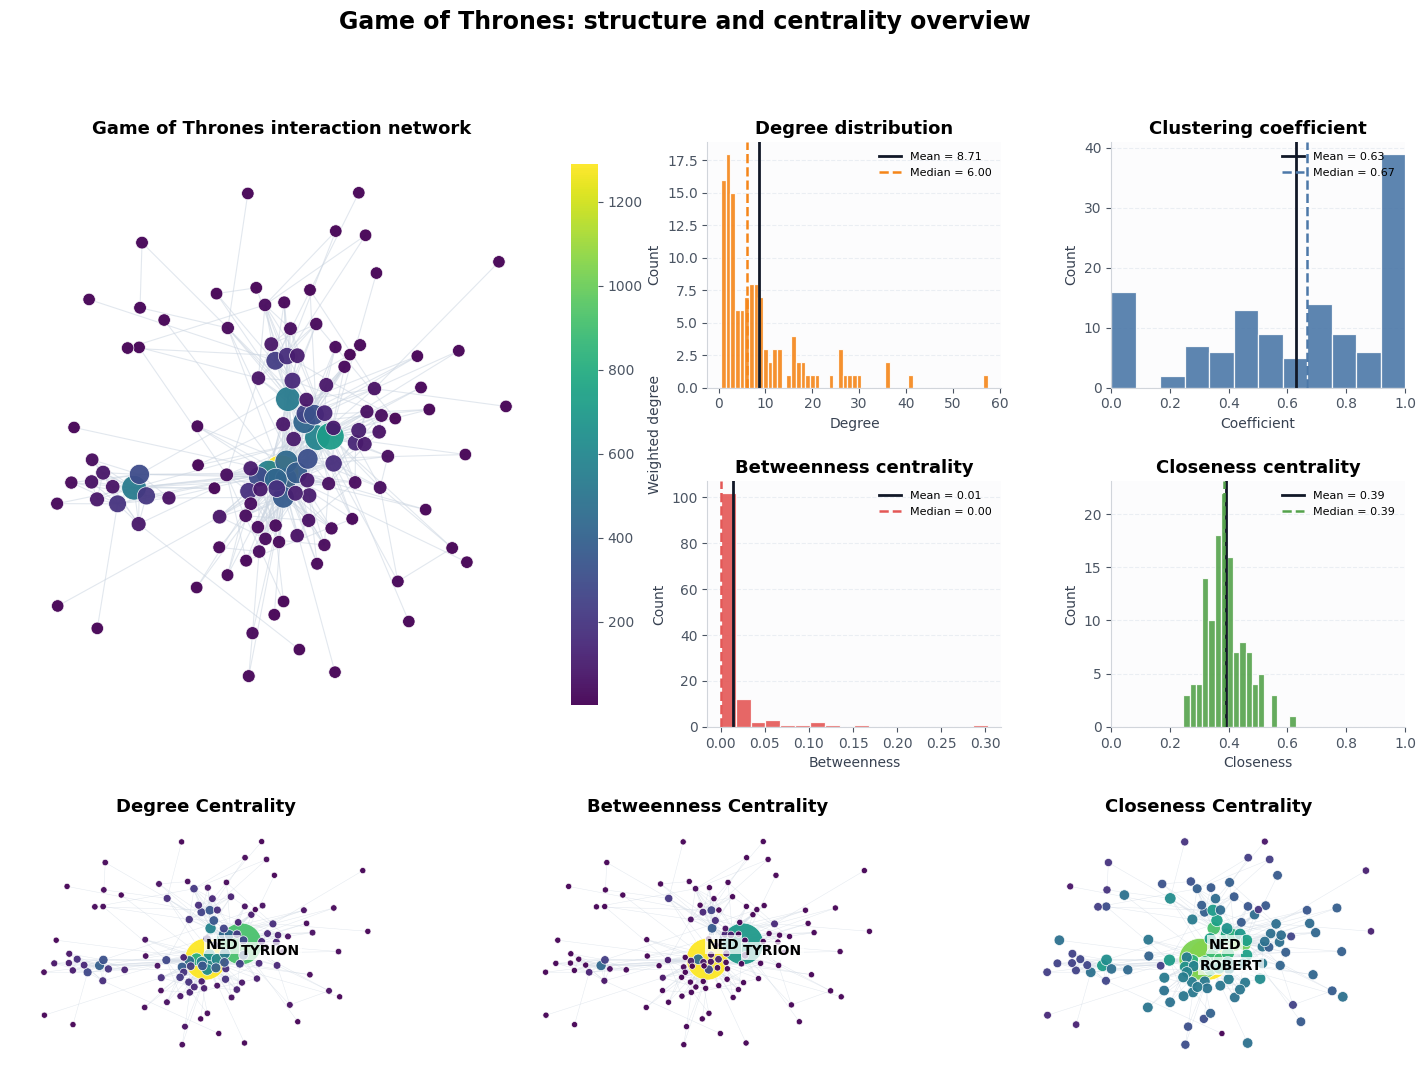

In [7]:
#@title Game of Thrones Graph

GoT = nx.Graph()
with open('got-s1-edges.csv') as csv_file:
    csv_reader = csv.DictReader(csv_file)
    for row in csv_reader:
        GoT.add_edge(row['Source'], row['Target'], weight=float(row['Weight']))

pos = nx.spring_layout(GoT, seed=40, k=0.55)

coef = nx.clustering(GoT)
cc_data = list(coef.values())
degrees = np.array([degree for _, degree in GoT.degree()], dtype=float)
deg_centrality = nx.degree_centrality(GoT)
betweenness = nx.betweenness_centrality(GoT)
bet_data = list(betweenness.values())
closeness = nx.closeness_centrality(GoT)
close_data = list(closeness.values())

def top_nodes(centrality_dict, n=3):
    return dict(sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:n])

top_deg = top_nodes(deg_centrality)
top_bet = top_nodes(betweenness)
top_close = top_nodes(closeness)

weighted_degree = np.array([GoT.degree(node, weight="weight") for node in GoT.nodes()], dtype=float)

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], width_ratios=[2, 1, 1], hspace=0.38, wspace=0.28)

ax1 = fig.add_subplot(gs[:2, 0])
nodes = draw_network_pretty(
    ax1,
    GoT,
    pos,
    title="Game of Thrones interaction network",
    node_values=weighted_degree,
    node_sizes=normalized_sizes(weighted_degree, 80, 650),
    edge_width=0.8,
)
cbar = fig.colorbar(nodes, ax=ax1, fraction=0.046, pad=0.03)
cbar.outline.set_visible(False)
cbar.set_label("Weighted degree")

ax2 = fig.add_subplot(gs[0, 2])
plot_distribution(ax2, cc_data, "Clustering coefficient", "Coefficient", PLOT_COLORS["clustering"], bins=12, xlim=(0, 1))

ax3 = fig.add_subplot(gs[0, 1])
plot_distribution(ax3, degrees, "Degree distribution", "Degree", PLOT_COLORS["degree"], discrete=True)

ax4 = fig.add_subplot(gs[1, 1])
plot_distribution(ax4, bet_data, "Betweenness centrality", "Betweenness", PLOT_COLORS["betweenness"], bins=18)

ax5 = fig.add_subplot(gs[1, 2])
plot_distribution(ax5, close_data, "Closeness centrality", "Closeness", PLOT_COLORS["closeness"], bins=18, xlim=(0, 1))

from matplotlib.gridspec import GridSpecFromSubplotSpec
inner_gs = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[2, :], wspace=0.28)

centralities = [
    ("Degree Centrality", deg_centrality),
    ("Betweenness Centrality", betweenness),
    ("Closeness Centrality", closeness),
]

for i, (title, cent_dict) in enumerate(centralities):
    ax = fig.add_subplot(inner_gs[0, i])

    node_metric = np.array([cent_dict[node] for node in GoT.nodes()])
    top_dict = dict(sorted(cent_dict.items(), key=lambda x: x[1], reverse=True)[:2])
    top_nodes_list = list(top_dict.keys())

    base_sizes = normalized_sizes(node_metric, 20, 120)
    highlight_sizes = [
        900 if node in top_nodes_list else size
        for node, size in zip(GoT.nodes(), base_sizes)
    ]

    draw_network_pretty(
        ax,
        GoT,
        pos,
        title=title,
        node_values=node_metric,
        node_sizes=highlight_sizes,
        edge_width=0.35,
        labels=None,
    )

    # manual label placement
    label_offsets = {
        top_nodes_list[0]: (0, 0.1),
        top_nodes_list[1]: (0, -0.1),
    }

    for node in top_nodes_list:
        x, y = pos[node]
        dx, dy = label_offsets[node]
        ax.text(
            x + dx, y + dy,
            node,
            fontsize=10,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
            zorder=10
        )

fig.suptitle("Game of Thrones: structure and centrality overview", fontsize=17, fontweight="bold", y=0.99)
plt.show()


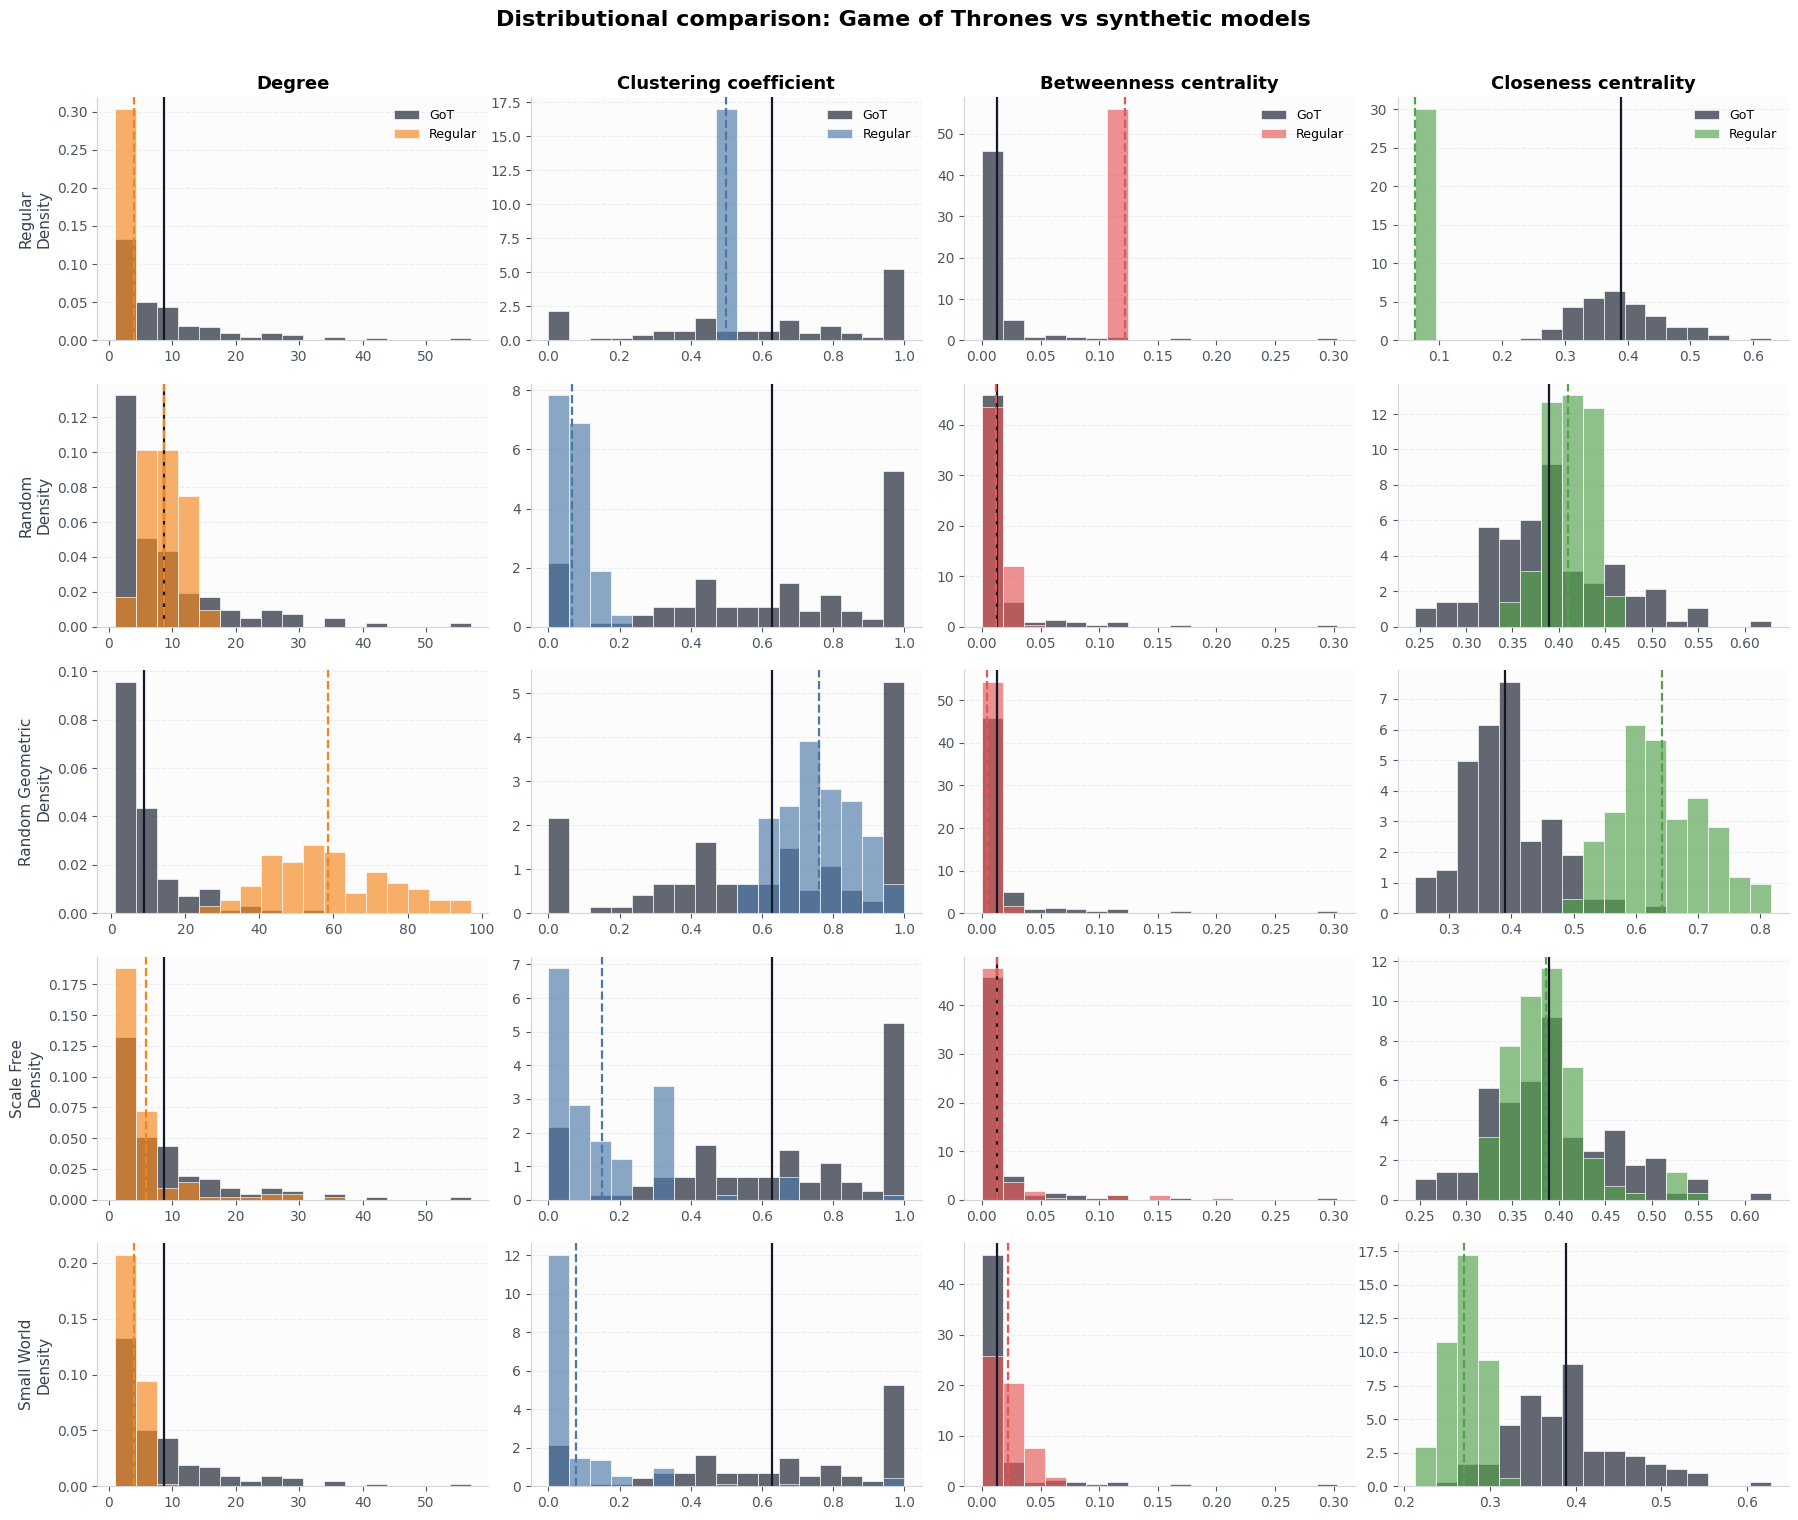

In [8]:
#@title GoT Graph Metrics Distribution
GoT = nx.Graph()
with open('got-s1-edges.csv') as csv_file:
    reader = csv.DictReader(csv_file)
    for row in reader:
        GoT.add_edge(row['Source'], row['Target'], weight=float(row['Weight']))

def get_metrics(G):
    return {
        "degree": [d for _, d in G.degree()],
        "clustering": list(nx.clustering(G).values()),
        "betweenness": list(nx.betweenness_centrality(G).values()),
        "closeness": list(nx.closeness_centrality(G).values()),
    }

got_metrics = get_metrics(GoT)
n_nodes = GoT.number_of_nodes()
n_edges = GoT.number_of_edges()

synthetic_models = [
    ("Regular", nx.watts_strogatz_graph(n=n_nodes, k=4, p=0, seed=42)),
    ("Random", nx.gnm_random_graph(n=n_nodes, m=n_edges, seed=42)),
    ("Random Geometric", nx.random_geometric_graph(n=n_nodes, radius=0.5, seed=42)),
    ("Scale Free", nx.barabasi_albert_graph(n=n_nodes, m=3, seed=42)),
    ("Small World", nx.watts_strogatz_graph(n=n_nodes, k=4, p=0.5, seed=42))
]

metric_names = ["degree", "clustering", "betweenness", "closeness"]
titles = {
    "degree": "Degree",
    "clustering": "Clustering coefficient",
    "betweenness": "Betweenness centrality",
    "closeness": "Closeness centrality",
}
metric_colors = {
    "degree": PLOT_COLORS["degree"],
    "clustering": PLOT_COLORS["clustering"],
    "betweenness": PLOT_COLORS["betweenness"],
    "closeness": PLOT_COLORS["closeness"],
}

fig, axes = plt.subplots(5, 4, figsize=(18, 15), sharex=False, sharey=False)
for row, (label, model_graph) in enumerate(synthetic_models):
    syn_metrics = get_metrics(model_graph)
    for col, metric in enumerate(metric_names):
        ax = axes[row, col]
        got_data = np.asarray(got_metrics[metric], dtype=float)
        syn_data = np.asarray(syn_metrics[metric], dtype=float)

        lower = min(got_data.min(), syn_data.min())
        upper = max(got_data.max(), syn_data.max())
        if np.isclose(lower, upper):
            upper = lower + 1
        bins = np.linspace(lower, upper, 18)

        ax.hist(got_data, bins=bins, density=True, alpha=0.65, color=PLOT_COLORS["accent"], edgecolor="white", linewidth=0.7, label="GoT")
        ax.hist(syn_data, bins=bins, density=True, alpha=0.65, color=metric_colors[metric], edgecolor="white", linewidth=0.7, label=label)

        ax.axvline(got_data.mean(), color=PLOT_COLORS["accent"], linewidth=1.6)
        ax.axvline(syn_data.mean(), color=metric_colors[metric], linewidth=1.6, linestyle="--")

        if row == 0:
            ax.set_title(titles[metric], fontsize=13, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{label}\nDensity", fontsize=11)
        else:
            ax.set_ylabel("")

        style_axis(ax, grid_axis="y")
        if row == 0:
            ax.legend(loc="upper right", fontsize=9)

fig.suptitle("Distributional comparison: Game of Thrones vs synthetic models", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [9]:
#@title Metrics comparison

GoT = nx.Graph()
with open("got-s1-edges.csv") as csv_file:
    reader = csv.DictReader(csv_file)
    for row in reader:
        GoT.add_edge(row["Source"], row["Target"], weight=float(row["Weight"]))
# print(nx.average_clustering(GoT))

n_nodes = GoT.number_of_nodes()
n_edges = GoT.number_of_edges()
avg_degree_target = round(2 * n_edges / n_nodes)

comparison_graphs = {
    "GoT": GoT,
    "Regular": nx.watts_strogatz_graph(n=n_nodes, k=4, p=0, seed=42),
    "Random": nx.gnm_random_graph(n=n_nodes, m=n_edges, seed=42),
    "Random Geometric": nx.random_geometric_graph(n=n_nodes, radius=0.25, seed=42),
    "Scale Free": nx.barabasi_albert_graph(n=n_nodes, m=max(1, avg_degree_target // 2), seed=42),
    "Small World": nx.watts_strogatz_graph(n=n_nodes, k=4, p=0.15, seed=42),
}

comparison_df = compare_model_summaries(comparison_graphs)
comparison_df


,name,nodes,edges,avg_degree,degree_std,avg_clustering,components,giant_component_ratio,avg_shortest_path_giant,diameter_giant
0,GoT,126,549,8.7143,9.4120,0.6297,1,1.0,2.6447,6
1,Regular,126,252,4.0000,0.0000,0.5000,1,1.0,16.1280,32
2,Random,126,549,8.7143,2.8670,0.0667,1,1.0,2.4510,4
3,Random Geometric,126,1183,18.7778,5.4290,0.6634,1,1.0,2.8750,6
4,Scale Free,126,488,7.7460,6.4709,0.1624,1,1.0,2.4347,4
5,Small World,126,252,4.0000,0.7559,0.3011,1,1.0,4.8234,10


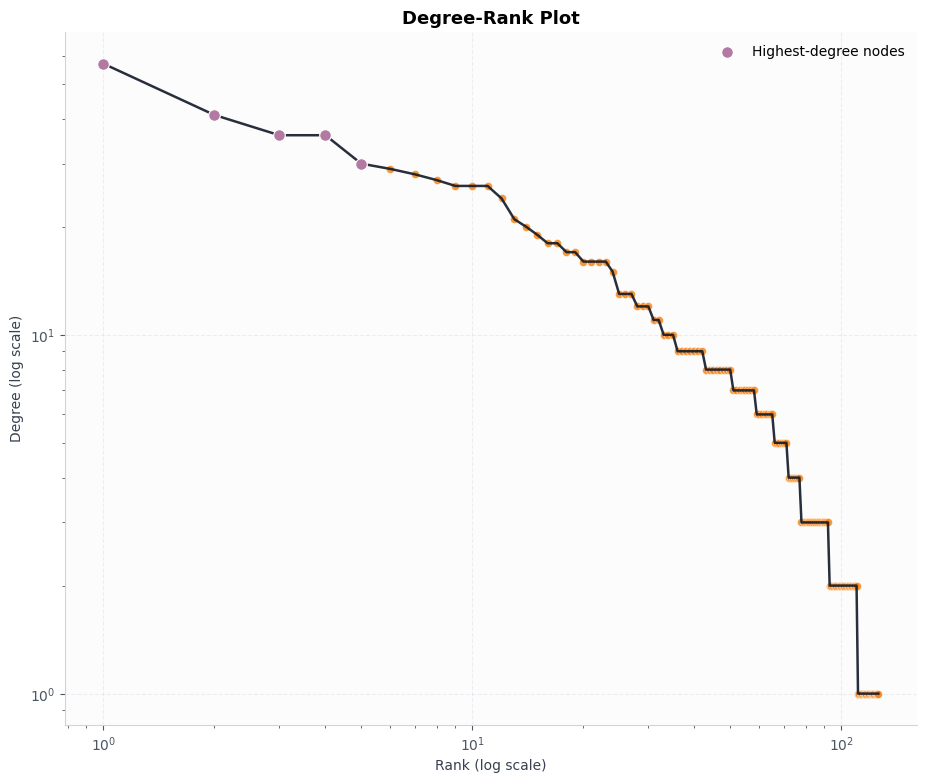

In [10]:
#@title Degree-Rank Plot
plot_degree_rank(GoT, "Degree-Rank Plot")

/tmp/ipykernel_601/454709303.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


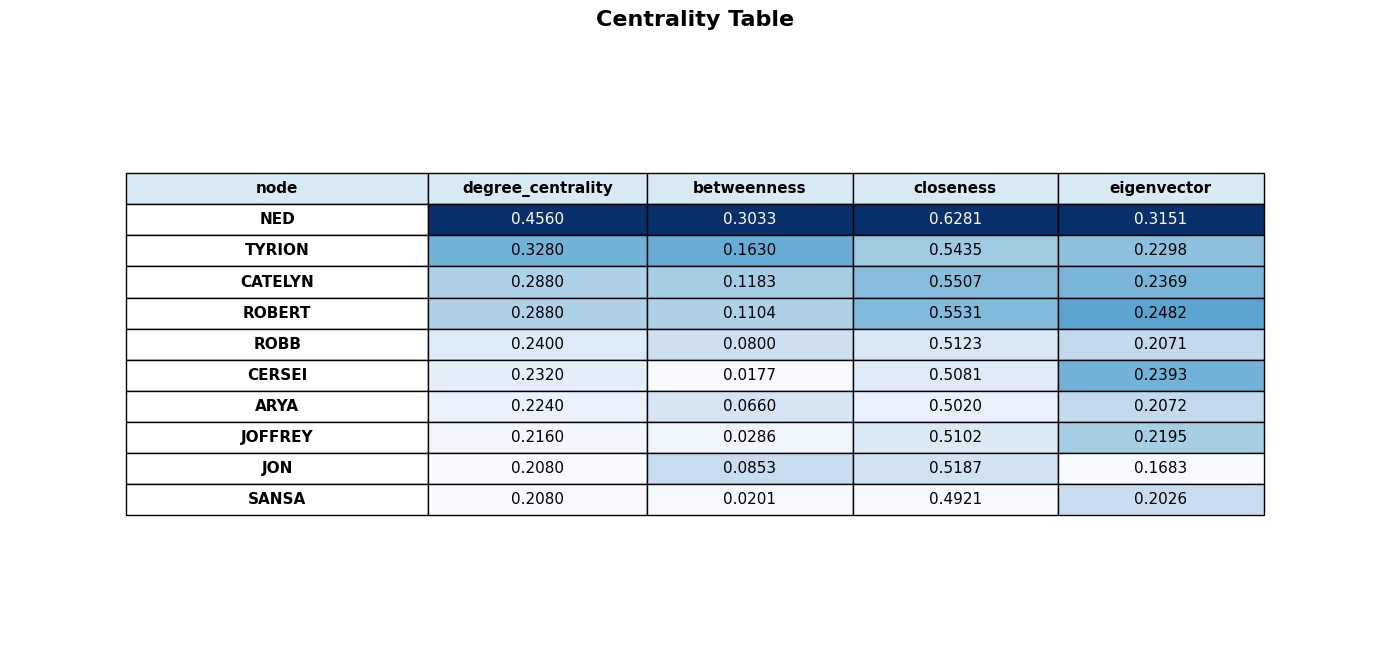

In [11]:
#@title Centrality Metrics for the most "important" character

def centrality_table_df(G, top_n=10):
    deg = nx.degree_centrality(G)
    bet = nx.betweenness_centrality(G)
    clo = nx.closeness_centrality(G)
    eig = nx.eigenvector_centrality_numpy(giant_component(G)) if G.number_of_nodes() > 1 else {}

    rows = []
    for node in G.nodes():
        rows.append({
            "node": node,
            "degree_centrality": deg.get(node, np.nan),
            "betweenness": bet.get(node, np.nan),
            "closeness": clo.get(node, np.nan),
            "eigenvector": eig.get(node, np.nan),
        })

    df = pd.DataFrame(rows).sort_values(
        by=["degree_centrality", "betweenness", "closeness"],
        ascending=False
    ).head(top_n).reset_index(drop=True)

    return df


def save_gradient_table(df, title="Centrality Table", filename="centrality_table.png", cmap_name="Blues"):
    df_display = df.copy()
    numeric_cols = [c for c in df.columns if c != "node"]

    for col in numeric_cols:
        df_display[col] = df_display[col].map(lambda x: f"{x:.4f}")

    nrows, ncols = df_display.shape
    fig_h = max(4.5, 0.55 * (nrows + 2))
    fig_w = 14

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=16, pad=16)

    table = ax.table(
        cellText=df_display.values,
        colLabels=df_display.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)

    cmap = cm.get_cmap(cmap_name)

    # column widths
    widths = [0.22, 0.16, 0.15, 0.15, 0.15, 0.12]

    # header styling
    for c in range(ncols):
        cell = table[(0, c)]
        cell.set_facecolor("#D9EAF7")
        cell.set_text_props(weight="bold", color="black")
        if c < len(widths):
            cell.set_width(widths[c])

    # body styling with gradient like pandas Styler
    for c, col in enumerate(df.columns):
        if c < len(widths):
            for r in range(1, nrows + 1):
                table[(r, c)].set_width(widths[c])

        if col == "node":
            for r in range(1, nrows + 1):
                cell = table[(r, c)]
                cell.set_facecolor("white")
                cell.set_text_props(weight="bold", color="black")
            continue

        vals = df[col].astype(float).values
        norm = mcolors.Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))

        for r in range(1, nrows + 1):
            val = df.iloc[r - 1][col]
            color = cmap(norm(val))
            cell = table[(r, c)]
            cell.set_facecolor(color)

            # darker cells -> white text
            if norm(val) > 0.6:
                cell.set_text_props(color="white")
            else:
                cell.set_text_props(color="black")

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

df_cent = centrality_table_df(GoT, top_n=10)

save_gradient_table(
    df_cent,
    title="Centrality Table",
    filename="GoT_centrality_table_top10.png",
    cmap_name="Blues"
)

Number of detected communities in giant component: 5
Modularity: 0.4685


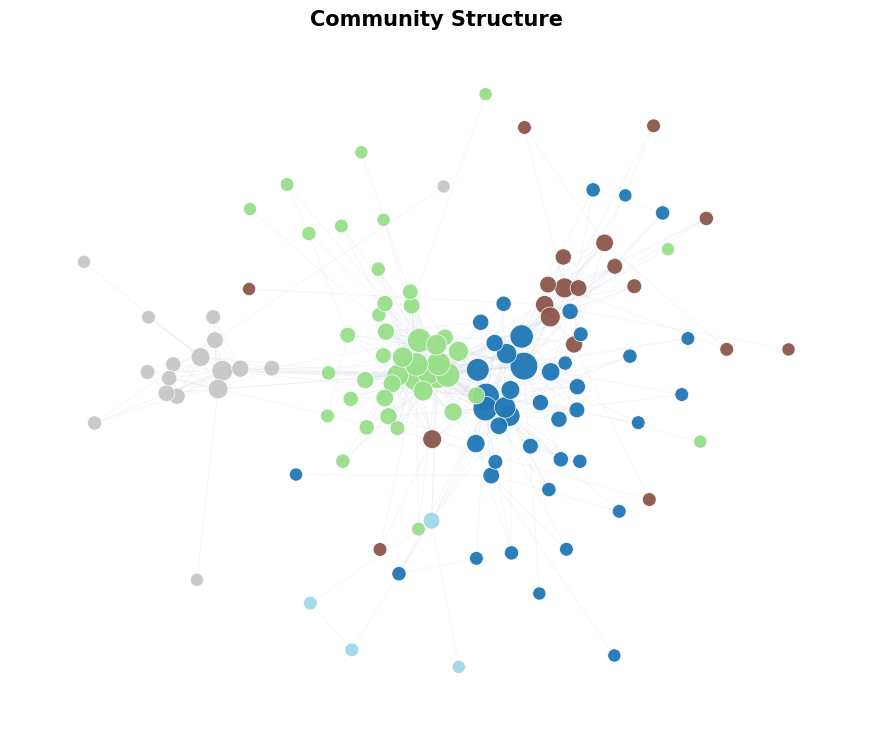

In [13]:
#@title Community detection on the Game of Thrones network

GoT_gc = giant_component(GoT)
communities = list(nx.algorithms.community.greedy_modularity_communities(GoT_gc))
modularity_value = nx.algorithms.community.modularity(GoT_gc, communities)

print(f"Number of detected communities in giant component: {len(communities)}")
print(f"Modularity: {modularity_value:.4f}")

pos = nx.spring_layout(GoT_gc, seed=42, k=0.55)
community_map = {}
for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i

community_values = np.array([community_map[node] for node in GoT_gc.nodes()])
degree_values = np.array([GoT_gc.degree(node) for node in GoT_gc.nodes()])
node_sizes = normalized_sizes(degree_values, 90, 520)

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(GoT_gc, pos, ax=ax, alpha=0.2, width=0.7, edge_color=PLOT_COLORS["edge"])
nodes = nx.draw_networkx_nodes(
    GoT_gc,
    pos,
    ax=ax,
    node_color=community_values,
    node_size=node_sizes,
    cmap="tab20",
    linewidths=0.5,
    edgecolors="white",
    alpha=0.95,
)

largest_community = max(communities, key=len)
top_in_largest = sorted(largest_community, key=lambda node: GoT_gc.degree(node), reverse=True)[:5]
# for node in top_in_largest:
#     x, y = pos[node]
#     ax.text(
#         x,
#         y + 0.03,
#         node,
#         fontsize=9,
#         ha="center",
#         color=PLOT_COLORS["accent"],
#         weight="bold",
#         bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.85),
#     )

ax.set_title("Community Structure", fontsize=15, fontweight="bold")
ax.axis("off")

plt.show()
